In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy.ndimage import gaussian_filter
import pandas as pd
import scipy.optimize
import math
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42

def weighted_avg_and_std(values, weights):
    """
    Return the weighted average and standard deviation.

    They weights are in effect first normalized so that they 
    sum to 1 (and so they must not all be 0).

    values, weights -- NumPy ndarrays with the same shape.
    """
    average = np.average(values, weights=weights)
    # Fast and numerically precise:
    variance = np.average((values-average)**2, weights=weights)
    return (average, math.sqrt(variance))


path = '/Volumes/Elements/PTM_project/SASA_FLN5_comparisons/delta6/'

In [8]:
# native

native = np.loadtxt(path+'native_6g4a/sasa.xvg',skiprows=25)[:,2]
I = np.loadtxt(path+'state_A/alldata.txt',skiprows=0)[:,2]

# make table

df = pd.DataFrame()
df['Proline state'] = ['cis','trans']
df['Avg SASA (nm^2)'] = [np.mean(native),np.mean(I)]
df['Error'] = [np.std(native),np.std(I)]
df.to_csv('FLN5_native_vs_delta6I_Met741_SASA_6g4a_stateA.csv')
df

,Proline state,Avg SASA (nm^2),Error
0,cis,0.138600,0.037235
1,trans,1.467094,0.171734


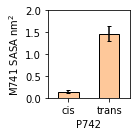

In [11]:
# plot
df = pd.read_csv('FLN5_native_vs_delta6I_Met741_SASA_6g4a_stateA.csv')
df.plot(x='Proline state',y='Avg SASA (nm^2)',yerr= np.array(df['Error']),
       kind='bar',figsize = (2,2),legend=False,color = '#FEC89A',edgecolor = 'black',
       capsize = 2)

plt.xticks(rotation=0)
plt.ylim(0,2)
plt.xlabel('P742')

plt.ylabel('M741 SASA nm$^{2}$')

plt.tight_layout()
plt.savefig('FLN5_native_vs_I_Met741_SASA_proline_states_barplot.pdf')